## 07 - TensorFlow Core Advanced (Learn After 06)

This notebook is the **second step** in your TensorFlow sequence.

Recommended order:
1. Graph compilation (`tf.function`, `tf.TensorSpec`)
2. Input pipelines (`tf.data.Dataset`)
3. Performance and precision (`tf.keras.mixed_precision`)
4. Stable optimization (`tf.clip_by_global_norm`)
5. Checkpointing (`tf.train.Checkpoint`, `tf.train.CheckpointManager`)
6. Distributed strategy basics (`tf.distribute.MirroredStrategy`)

---

## TensorFlow API Tutorial (Only `tf` Classes/Functions)

### 1) `tf.function`
Documentation: https://www.tensorflow.org/api_docs/python/tf/function  
Use case: compile Python TensorFlow code into graphs for speed and deployment portability.

Do:
- Use when logic is repeatedly executed (training steps, inference loops).
- Provide stable input shapes/dtypes when possible.

Don't:
- Mix heavy Python side effects expecting them to run every step.

Tips and tricks:
- Add `input_signature` with `tf.TensorSpec` to reduce retracing.

Edge condition:
- Frequent shape/dtype changes cause retracing and large overhead.

### 2) `tf.data.Dataset`
Documentation: https://www.tensorflow.org/api_docs/python/tf/data/Dataset  
Use case: scalable data pipelines with shuffle, batch, prefetch.

Do:
- Use `shuffle(...).batch(...).prefetch(tf.data.AUTOTUNE)`.

Don't:
- Materialize huge datasets into Python lists before dataset creation.

Tips and tricks:
- Cache only if data fits memory and is reused across epochs.

Edge condition:
- Incorrect shuffle buffer can reduce randomness and hurt generalization.

### 3) `tf.keras.mixed_precision.set_global_policy`
Documentation: https://www.tensorflow.org/api_docs/python/tf/keras/mixed_precision/set_global_policy  
Use case: faster training and lower memory on supported hardware.

Do:
- Keep losses and critical reductions numerically stable.

Don't:
- Assume all hardware benefits equally.

Tips and tricks:
- Evaluate accuracy drift after enabling mixed precision.

Edge condition:
- Very small gradients may underflow in float16 without proper loss scaling.

### 4) `tf.clip_by_global_norm`
Documentation: https://www.tensorflow.org/api_docs/python/tf/clip_by_global_norm  
Use case: prevent exploding gradients.

Do:
- Clip gradients before `optimizer.apply_gradients`.

Don't:
- Clip blindly with a too-small threshold; you can stall learning.

Tips and tricks:
- Track gradient norms over time to choose clipping threshold.

Edge condition:
- If gradients are `None`, filter them before clipping.

### 5) `tf.train.Checkpoint` and `tf.train.CheckpointManager`
Documentation:  
- https://www.tensorflow.org/api_docs/python/tf/train/Checkpoint  
- https://www.tensorflow.org/api_docs/python/tf/train/CheckpointManager

Use case: robust model/optimizer state saving and restore.

Do:
- Save both model and optimizer states.

Don't:
- Restore weights only when optimizer momentum state is required.

Tips and tricks:
- Keep latest N checkpoints to balance safety and storage.

Edge condition:
- Architecture changes can make old checkpoints partially incompatible.

### 6) `tf.distribute.MirroredStrategy`
Documentation: https://www.tensorflow.org/api_docs/python/tf/distribute/MirroredStrategy  
Use case: single-machine multi-GPU data parallel training.

Do:
- Create model/optimizer in strategy scope.

Don't:
- Mix replica-local logic with global reduction incorrectly.

Tips and tricks:
- Validate per-replica loss reduction semantics early.

Edge condition:
- Batch sizes not divisible across replicas can produce uneven work.

---

## Summary (07)

After finishing this notebook, you should be able to:
- Convert eager steps to graph-compiled execution safely.
- Build production-style data pipelines and checkpoint workflows.
- Improve throughput with mixed precision and distributed execution.
- Handle performance and stability edge cases with measurable safeguards.

In [1]:
# Standalone notebook setup (required imports)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.22.0-dev0+selfbuilt
NumPy: 2.4.2


In [ ]:
import importlib.util
import os


def load_runtime_env() -> None:
    candidate_paths = [
        os.path.join(os.getcwd(), "configs", "runtime.env"),
        os.path.join(os.getcwd(), "configs", "runtime.env.example"),
        os.path.join(os.getcwd(), "..", "configs", "runtime.env"),
        os.path.join(os.getcwd(), "..", "configs", "runtime.env.example"),
    ]
    for path in candidate_paths:
        if not os.path.exists(path):
            continue
        with open(path, "r", encoding="utf-8") as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip().strip("\"'")
                if key and key not in os.environ:
                    os.environ[key] = value
        break


def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}


load_runtime_env()
USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))
NO_CUDA = not USE_GPU

_torch_cuda = False
_tf_gpu = False
if importlib.util.find_spec("torch") is not None:
    import torch

    _torch_cuda = torch.cuda.is_available()
if importlib.util.find_spec("tensorflow") is not None:
    import tensorflow as tf

    _tf_gpu = bool(tf.config.list_physical_devices("GPU"))

RUNTIME_DEVICE = "cuda" if USE_GPU and (_torch_cuda or _tf_gpu) else "cpu"
print(f"USE_GPU={int(USE_GPU)} | runtime_device={RUNTIME_DEVICE}")

In [11]:
# Quick API practice (07): advanced tf workflow with inline comments

# 1) tf.function with stable input signature to avoid retracing
@tf.function(input_signature=[tf.TensorSpec(shape=[None, 4], dtype=tf.float32)])
def fast_step(x):
    # Compiled graph operation for repeated execution
    return tf.reduce_sum(tf.square(x), axis=1)

sample_x = tf.random.normal([8, 4])
compiled_out = fast_step(sample_x)

# 2) tf.data pipeline for scalable input handling
# Build dataset -> shuffle -> batch -> prefetch for throughput
ds = tf.data.Dataset.from_tensor_slices(sample_x)
ds = ds.shuffle(buffer_size=8).batch(4).prefetch(tf.data.AUTOTUNE)

# 3) Gradient clipping with global norm in a minimal training-like step
v = tf.Variable(tf.random.normal([4, 1]))
with tf.GradientTape() as tape:
    pred = tf.matmul(sample_x, v)
    adv_loss = tf.reduce_mean(tf.square(pred - 0.0))
raw_grads = tape.gradient(adv_loss, [v])
# Filter None gradients if graph has disconnected paths
raw_grads = [g for g in raw_grads if g is not None]
clipped_grads, global_norm = tf.clip_by_global_norm(raw_grads, clip_norm=1.0)

# 4) Mixed precision policy setup (global setting)
# Demonstrate policy change, then reset to float32 for notebook safety.
tf.keras.mixed_precision.set_global_policy('mixed_float16')
policy_name = tf.keras.mixed_precision.global_policy().name

print('Compiled output shape:', compiled_out.shape)
print('One dataset batch shape:', next(iter(ds)).shape)
print('Global gradient norm (pre-clip):', float(global_norm.numpy()))
print('Mixed precision policy (demo):', policy_name)

# Reset to common baseline policy to avoid side effects for later cells.
tf.keras.mixed_precision.set_global_policy('float32')
print('Mixed precision policy (restored):', tf.keras.mixed_precision.global_policy().name)

Compiled output shape: (8,)
One dataset batch shape: (4, 4)
Global gradient norm (pre-clip): 7.2728681564331055
Mixed precision policy (demo): mixed_float16
Mixed precision policy (restored): float32


## Code Logic Walkthrough (07)

This notebook extends core TensorFlow concepts into performance, production patterns, and enterprise reliability. The logic of each code block is summarized below.

1. **Standalone setup**
   - Imports required libraries and seeds randomness for reproducibility.

2. **Benchmarking and profiling**
   - Defines reusable timing helpers.
   - Compares operation classes (matrix ops, reductions, eager vs graph training steps).
   - Converts timing data into throughput and visual diagnostics.

3. **Mixed precision workflow**
   - Applies a mixed-precision policy and compares memory footprint.
   - Uses loss scaling to preserve gradient signal when compute dtype is lower precision.

4. **`@tf.function` optimization**
   - Compares eager execution to graph execution.
   - Demonstrates retracing behavior and input signatures.
   - Benchmarks graph-compiled training functions.

5. **Use case: CNN image classification**
   - Prepares data pipeline and model architecture.
   - Runs train/validation loop with metric tracking.
   - Evaluates test performance and visualizes predictions.

6. **Use case: tabular regression**
   - Normalizes features/targets, trains linear model, and validates convergence.
   - Uses scatter diagnostics and `$R^2$`-style fit quality checks.

7. **Shape and dtype edge-case handling**
   - Reproduces shape mismatch and broadcasting failures intentionally.
   - Demonstrates reshape/cast repair patterns and safer tensor transformations.

8. **Enterprise edge-case catalog**
   - Collects practical failure modes: overflow/underflow, exploding gradients, side effects in graph mode, unstable softmax/CE.
   - Adds robust patterns: clipping, numerically stable APIs, NaN-guard loops, custom gradients, checkpoint restore, and distributed-reduction consistency.

Use this notebook as an "advanced systems" guide: each section moves from concept demonstration to production-safe implementation patterns.


Benchmarking and Profiling

Basic Benchmarking with tf.timestamp():


Benchmarking Different Operations:
Matrix Multiplication (1000x1000):
  Mean: 0.1236 ms
  Std: 0.0380 ms
  Min: 0.0780 ms
  Max: 0.3412 ms
Element-wise Addition (1000x1000):
  Mean: 0.1073 ms
  Std: 0.0320 ms
  Min: 0.0401 ms
  Max: 0.2499 ms
Reduce Sum (1000x1000):
  Mean: 0.1529 ms
  Std: 0.0451 ms
  Min: 0.1018 ms
  Max: 0.4411 ms


Vectorization Impact:
Python Loop Sum (10000 elements):
  Mean: 0.5532 ms
  Std: 0.0502 ms
  Min: 0.5019 ms
  Max: 0.6890 ms
TensorFlow Sum (10000 elements):
  Mean: 1.5338 ms
  Std: 0.3343 ms
  Min: 1.1160 ms
  Max: 2.5291 ms

Vectorization Speedup: 0.4x faster with TensorFlow


Training Step Benchmarking:


/home/dc-apps/APPS_VENV/python_venv/run_3_14_2/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Step (Eager):
  Mean: 18.4414 ms
  Std: 2.2798 ms
  Min: 14.9801 ms
  Max: 25.8679 ms
Training Step (Graph):
  Mean: 2.1576 ms
  Std: 0.9962 ms
  Min: 1.3309 ms
  Max: 6.8879 ms

Graph Speedup: 8.55x faster with @tf.function


Throughput Analysis:
Batch size 32:
  Mean: 2.0204 ms
  Std: 0.7644 ms
  Min: 1.4341 ms
  Max: 4.2539 ms
  Batch 32: 15838.5 samples/second
Batch size 64:
  Mean: 1.9601 ms
  Std: 0.5658 ms
  Min: 1.3511 ms
  Max: 3.6290 ms
  Batch 64: 32652.0 samples/second
Batch size 128:
  Mean: 2.2005 ms
  Std: 0.8454 ms
  Min: 1.2891 ms
  Max: 4.9200 ms
  Batch 128: 58167.8 samples/second
Batch size 256:
  Mean: 2.0384 ms
  Std: 0.5810 ms
  Min: 1.3840 ms
  Max: 3.6020 ms
  Batch 256: 125589.0 samples/second


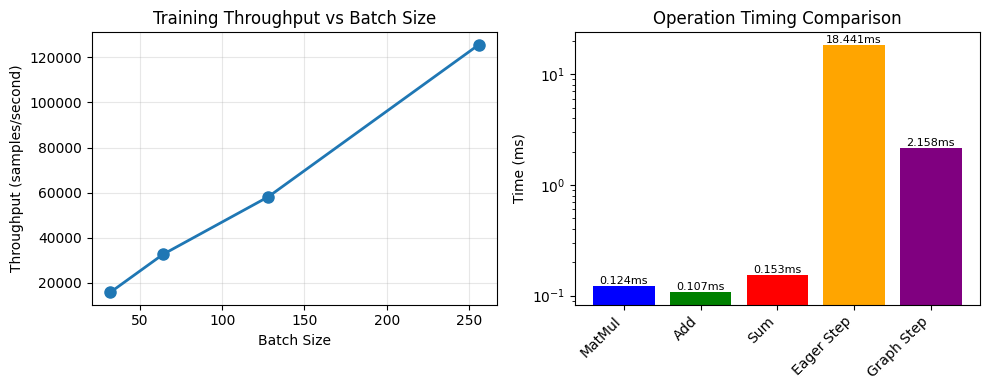


Benchmarking completed!


In [2]:
print("\n" + "=" * 60)
print("Benchmarking and Profiling")
print("=" * 60)

# 1. Basic benchmarking with tf.timestamp
print("\nBasic Benchmarking with tf.timestamp():")

def benchmark_operation(op_fn, name, iterations=100):
    """Benchmark a TensorFlow operation"""
    
    # Warmup
    for _ in range(10):
        op_fn()
    
    # Measure
    times = []
    for _ in range(iterations):
        start = tf.timestamp()
        op_fn()
        end = tf.timestamp()
        times.append((end - start).numpy())
    
    times_ms = np.array(times) * 1000  # Convert to milliseconds
    
    print(f"{name}:")
    print(f"  Mean: {times_ms.mean():.4f} ms")
    print(f"  Std: {times_ms.std():.4f} ms")
    print(f"  Min: {times_ms.min():.4f} ms")
    print(f"  Max: {times_ms.max():.4f} ms")
    
    return times_ms

# 2. Benchmark different tensor operations
print("\n\nBenchmarking Different Operations:")

x = tf.random.normal((1000, 1000))
y = tf.random.normal((1000, 1000))

# Matrix multiplication
matmul_times = benchmark_operation(
    lambda: tf.matmul(x, y),
    "Matrix Multiplication (1000x1000)"
)

# Element-wise addition
add_times = benchmark_operation(
    lambda: x + y,
    "Element-wise Addition (1000x1000)"
)

# Reduction (sum)
sum_times = benchmark_operation(
    lambda: tf.reduce_sum(x),
    "Reduce Sum (1000x1000)"
)

# 3. Vectorization benchmark (Python loop vs TensorFlow ops)
print("\n\nVectorization Impact:")

def python_loop_sum(n=10000):
    """Compute sum using Python loop"""
    x = np.random.randn(n)
    total = 0
    for val in x:
        total += val
    return total

def tensorflow_sum(n=10000):
    """Compute sum using TensorFlow"""
    x = tf.random.normal((n,))
    return tf.reduce_sum(x).numpy()

# Benchmark
python_times = benchmark_operation(
    lambda: python_loop_sum(10000),
    "Python Loop Sum (10000 elements)",
    iterations=20
)

tf_times = benchmark_operation(
    lambda: tensorflow_sum(10000),
    "TensorFlow Sum (10000 elements)",
    iterations=20
)

print(f"\nVectorization Speedup: {python_times.mean() / tf_times.mean():.1f}x faster with TensorFlow")

# 4. Training step benchmarking
print("\n\nTraining Step Benchmarking:")

# Simple model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)
])

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Training step without @tf.function
def train_step_eager(x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss = loss_fn(y, logits)
    
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

# Training step with @tf.function
@tf.function
def train_step_graph(x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss = loss_fn(y, logits)
    
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

# Generate dummy batch
x_batch = tf.random.normal((128, 20))
y_batch = tf.random.uniform((128,), maxval=10, dtype=tf.int32)

# Benchmark
eager_times = benchmark_operation(
    lambda: train_step_eager(x_batch, y_batch),
    "Training Step (Eager)",
    iterations=50
)

graph_times = benchmark_operation(
    lambda: train_step_graph(x_batch, y_batch),
    "Training Step (Graph)",
    iterations=50
)

print(f"\nGraph Speedup: {eager_times.mean() / graph_times.mean():.2f}x faster with @tf.function")

# 5. Throughput analysis
print("\n\nThroughput Analysis:")

batch_sizes = [32, 64, 128, 256]
throughputs = []

for batch_size in batch_sizes:
    x_batch = tf.random.normal((batch_size, 20))
    y_batch = tf.random.uniform((batch_size,), maxval=10, dtype=tf.int32)
    
    times_ms = benchmark_operation(
        lambda: train_step_graph(x_batch, y_batch),
        f"Batch size {batch_size}",
        iterations=20
    )
    
    throughput = batch_size / (times_ms.mean() / 1000)  # samples/second
    throughputs.append(throughput)
    print(f"  Batch {batch_size}: {throughput:.1f} samples/second")

# Plot throughput
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(batch_sizes, throughputs, marker='o', linewidth=2, markersize=8)
plt.xlabel('Batch Size')
plt.ylabel('Throughput (samples/second)')
plt.title('Training Throughput vs Batch Size')
plt.grid(True, alpha=0.3)

# Comparison of all benchmarks
plt.subplot(1, 2, 2)
operations = ['MatMul', 'Add', 'Sum', 'Eager Step', 'Graph Step']
times_comparison = [
    matmul_times.mean(),
    add_times.mean(),
    sum_times.mean(),
    eager_times.mean(),
    graph_times.mean()
]

bars = plt.bar(operations, times_comparison, color=['blue', 'green', 'red', 'orange', 'purple'])
plt.ylabel('Time (ms)')
plt.title('Operation Timing Comparison')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, time_val in zip(bars, times_comparison):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{time_val:.3f}ms', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nBenchmarking completed!")

## Section 13: Benchmarking and Profiling

**Why Benchmark?**
- Identify performance bottlenecks
- Measure impact of optimizations
- Compare different implementations
- Monitor training progress

**Benchmarking Tools:**
- `tf.timestamp()`: Measure execution time
- `timeit`: Python standard library
- TensorFlow Profiler: Detailed analysis

**What to Measure:**
- Training/inference time per step
- Memory usage
- GPU vs CPU efficiency
- Throughput (samples/second)

In [3]:
print("\n" + "=" * 60)
print("Performance: Mixed Precision Training")
print("=" * 60)

# 1. Setup mixed precision policy
print("\nSetting up Mixed Precision Policy:")

policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

print(f"Compute dtype: {policy.compute_dtype}")
print(f"Variable dtype: {policy.variable_dtype}")

# 2. Compare memory usage
print("\n\nMemory Usage Comparison:")

# Float32 model
def create_model(dtype):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', dtype=dtype),
        tf.keras.layers.Dense(128, activation='relu', dtype=dtype),
        tf.keras.layers.Dense(64, activation='relu', dtype=dtype),
        tf.keras.layers.Dense(10, dtype=dtype)
    ])
    return model

model_fp32 = create_model(tf.float32)
model_fp16 = create_model(tf.float16)

# Build models by passing dummy input so trainable_variables are populated
dummy_input = tf.random.normal((1, 20))
_ = model_fp32(dummy_input)
_ = model_fp16(tf.cast(dummy_input, tf.float16))

# Count parameters
def count_params(model):
    total = 0
    for var in model.trainable_variables:
        total += tf.size(var).numpy()
    return total

params_fp32 = count_params(model_fp32)
params_fp16 = count_params(model_fp16)

print(f"FP32 model params: {params_fp32}")
print(f"FP16 model params: {params_fp16}")

# Estimate memory (bytes)
memory_fp32 = params_fp32 * 4  # 4 bytes per float32
memory_fp16 = params_fp16 * 2  # 2 bytes per float16
print(f"FP32 memory: {memory_fp32/1024:.2f} KB")
print(f"FP16 memory: {memory_fp16/1024:.2f} KB")
print(f"Memory reduction: {(1 - memory_fp16/memory_fp32)*100:.1f}%")

# 3. Training with loss scaling
print("\n\nMixed Precision Training with Loss Scaling:")

# Reset policy
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(10)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Gradient scaling to prevent float16 underflow
loss_scale = tf.Variable(1e3, trainable=False, dtype=tf.float32)

@tf.function
def train_step_mixed_precision(x, y):
    with tf.GradientTape() as tape:
        # Compute in float16
        logits = model(x)

        # Compute loss
        unscaled_loss = loss_fn(y, logits)

        # Scale loss to prevent underflow
        scaled_loss = unscaled_loss * loss_scale

    # Compute gradients of scaled loss
    scaled_gradients = tape.gradient(scaled_loss, model.trainable_variables)

    # Unscale gradients (cast to float32 for safety)
    gradients = [tf.cast(g, tf.float32) / loss_scale for g in scaled_gradients]

    # Check for NaN/Inf using graph-compatible ops (tf.reduce_any + tf.cond)
    nan_flags = tf.stack([tf.reduce_any(tf.math.is_nan(g)) for g in gradients])
    has_nan = tf.reduce_any(nan_flags)

    def apply_grads():
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        loss_scale.assign(loss_scale * 1.001)

    def skip_grads():
        loss_scale.assign(loss_scale / 2)

    tf.cond(has_nan, skip_grads, apply_grads)

    return unscaled_loss

# Generate dummy training data
x_train_dummy = tf.random.normal((128, 20))
y_train_dummy = tf.random.uniform((128,), maxval=10, dtype=tf.int32)

print("\nTraining with mixed precision:")
for epoch in range(5):
    loss = train_step_mixed_precision(x_train_dummy, y_train_dummy)
    print(f"  Epoch {epoch+1}: Loss = {loss.numpy():.4f}, Loss scale = {loss_scale.numpy():.1f}")

# 4. Verify model predictions work with automatic casting
print("\n\nAutomatic Mixed Precision Benefits:")

# Standard evaluation
x_eval = tf.random.normal((32, 20))
predictions = model(x_eval)
print(f"Model output dtype: {predictions.dtype}")
print(f"Output shape: {predictions.shape}")

# Reset policy to default
tf.keras.mixed_precision.set_global_policy('float32')



Performance: Mixed Precision Training

Setting up Mixed Precision Policy:
Compute dtype: float16
Variable dtype: float32


Memory Usage Comparison:
FP32 model params: 47178
FP16 model params: 47178
FP32 memory: 184.29 KB
FP16 memory: 92.14 KB
Memory reduction: 50.0%


Mixed Precision Training with Loss Scaling:

Training with mixed precision:
  Epoch 1: Loss = 2.3474, Loss scale = 1001.0
  Epoch 2: Loss = 2.3220, Loss scale = 1002.0
  Epoch 3: Loss = 2.2971, Loss scale = 1003.0
  Epoch 4: Loss = 2.2728, Loss scale = 1004.0
  Epoch 5: Loss = 2.2492, Loss scale = 1005.0


Automatic Mixed Precision Benefits:
Model output dtype: <dtype: 'float16'>
Output shape: (32, 10)


## Section 12: Performance - Mixed Precision Training

**Why Mixed Precision?**
- Float16: 2x faster, uses 2x less memory, less precision
- Float32: Slower, more memory, better precision
- Solution: Compute in float16, accumulate in float32

**Benefits:**
- 2-3x faster training on GPUs
- 50% less memory usage
- Similar model accuracy

**Edge Cases:**
- Loss scaling: Prevent float16 underflow
- Gradient accumulation: Handle small gradients
- Numerical stability: Monitor for NaN/Inf

In [4]:
print("\n" + "=" * 60)
print("Performance Optimization: @tf.function")
print("=" * 60)

# 1. Eager vs Graph execution
print("\nEager vs Graph Execution Comparison:")

# Create weights outside functions (tf.Variable must not be created inside @tf.function)
W1 = tf.Variable(tf.random.normal((100, 50)))
W2 = tf.Variable(tf.random.normal((50, 10)))

# Define computationally intensive function
def compute_loss(x, y):
    """Complex loss computation"""
    pred = tf.nn.relu(tf.matmul(x, W1))
    pred = tf.nn.relu(tf.matmul(pred, W2))
    loss = tf.reduce_mean((pred - y)**2)
    return loss

# Graph version
@tf.function
def compute_loss_graph(x, y):
    """Same computation but with @tf.function"""
    pred = tf.nn.relu(tf.matmul(x, W1))
    pred = tf.nn.relu(tf.matmul(pred, W2))
    loss = tf.reduce_mean((pred - y)**2)
    return loss

# Generate test data
x_test = tf.random.normal((32, 100))
y_test = tf.random.normal((32, 10))

# Warmup to avoid first-call overhead
_ = compute_loss(x_test, y_test)
_ = compute_loss_graph(x_test, y_test)

# Benchmark
n_runs = 100

# Eager execution
import time
start = time.time()
for _ in range(n_runs):
    _ = compute_loss(x_test, y_test)
eager_time = time.time() - start

# Graph execution
start = time.time()
for _ in range(n_runs):
    _ = compute_loss_graph(x_test, y_test)
graph_time = time.time() - start

print(f"Eager execution: {eager_time:.4f}s ({n_runs} runs)")
print(f"Graph execution: {graph_time:.4f}s ({n_runs} runs)")
print(f"Speedup: {eager_time/graph_time:.2f}x faster with @tf.function")

# 2. Input signature and tracing
print("\n\nInput Signature and Retracing:")

call_count = 0

@tf.function
def add_numbers(x, y):
    global call_count
    call_count += 1
    return x + y

print(f"Call count: {call_count}")

# First call with shape (2, 3)
result1 = add_numbers(tf.ones((2, 3)), tf.ones((2, 3)))
print(f"After call with (2, 3): count = {call_count} (tracing occurred)")

# Second call with same shape
result2 = add_numbers(tf.ones((2, 3)), tf.ones((2, 3)))
print(f"After call with (2, 3): count = {call_count} (no retrace)")

# Third call with different shape
result3 = add_numbers(tf.ones((3, 4)), tf.ones((3, 4)))
print(f"After call with (3, 4): count = {call_count} (retrace occurred)")

# 3. Explicit input signature
print("\n\nExplicit Input Signature (Prevents Retracing):")

@tf.function(input_signature=[
    tf.TensorSpec(shape=None, dtype=tf.float32),
    tf.TensorSpec(shape=None, dtype=tf.float32)
])
def flexible_add(x, y):
    return x + y

# These won't cause retracing
print("Calling with different shapes (no retrace):")
print(f"  (2, 3): {flexible_add(tf.ones((2, 3)), tf.ones((2, 3))).shape}")
print(f"  (5, 5): {flexible_add(tf.ones((5, 5)), tf.ones((5, 5))).shape}")

# 4. tf.function with training
print("\n\nUsing @tf.function for Training:")

class FastModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(10)
    
    def call(self, x, training=False):
        x = self.dense1(x)
        return self.dense2(x)

model = FastModel()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Graph-compiled training step
@tf.function
def train_step_fast(x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
    
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

# Generate dummy data
x_dummy = tf.random.normal((128, 20))
y_dummy = tf.random.uniform((128,), maxval=10, dtype=tf.int32)

# Benchmark training
print("Benchmarking training with @tf.function:")
start = time.time()
for _ in range(100):
    _ = train_step_fast(x_dummy, y_dummy)
graph_train_time = time.time() - start

print(f"  Time for 100 training steps: {graph_train_time:.4f}s")
print(f"  Time per step: {graph_train_time/100*1000:.2f}ms")



Performance Optimization: @tf.function

Eager vs Graph Execution Comparison:
Eager execution: 0.0373s (100 runs)
Graph execution: 0.0415s (100 runs)
Speedup: 0.90x faster with @tf.function


Input Signature and Retracing:
Call count: 0
After call with (2, 3): count = 1 (tracing occurred)
After call with (2, 3): count = 1 (no retrace)
After call with (3, 4): count = 2 (retrace occurred)


Explicit Input Signature (Prevents Retracing):
Calling with different shapes (no retrace):
  (2, 3): (2, 3)
  (5, 5): (5, 5)


Using @tf.function for Training:
Benchmarking training with @tf.function:
  Time for 100 training steps: 0.3781s
  Time per step: 3.78ms


## Section 11: Performance Optimization with @tf.function

**What is @tf.function?**
- Decorator that converts Python functions to TensorFlow graphs
- Eager execution (default): Dynamic, flexible, slower
- Graph execution: Pre-compiled, faster, less flexible

**Performance Benefits:**
- Eliminates Python interpreter overhead
- Enables compiler optimizations
- Supports automatic parallelization and device placement

**Tradeoffs:**
- Limited to operations supported in graphs
- Harder to debug
- Retracing overhead for dynamic inputs


Use Case 2: MNIST Digit Classification (CNN)

Dataset Info:
  Training: (5000, 28, 28, 1) → (5000, 10)
  Validation: (1000, 28, 28, 1) → (1000, 10)
  Test: (10000, 28, 28, 1)

Training CNN Model...
Epoch  1: Train Loss = 0.7714, Val Loss = 0.2389, Val Acc = 0.9230
Epoch  2: Train Loss = 0.2102, Val Loss = 0.1653, Val Acc = 0.9400
Epoch  3: Train Loss = 0.1295, Val Loss = 0.1095, Val Acc = 0.9650
Epoch  4: Train Loss = 0.0976, Val Loss = 0.1033, Val Acc = 0.9660
Epoch  5: Train Loss = 0.0735, Val Loss = 0.0998, Val Acc = 0.9620
Epoch  6: Train Loss = 0.0538, Val Loss = 0.1032, Val Acc = 0.9650
Epoch  7: Train Loss = 0.0386, Val Loss = 0.1003, Val Acc = 0.9680
Epoch  8: Train Loss = 0.0299, Val Loss = 0.0978, Val Acc = 0.9720
Epoch  9: Train Loss = 0.0248, Val Loss = 0.0867, Val Acc = 0.9740
Epoch 10: Train Loss = 0.0189, Val Loss = 0.0840, Val Acc = 0.9760

Test Loss: 0.0769, Test Accuracy: 0.9775


/tmp/ipykernel_6625/3902950929.py:196: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


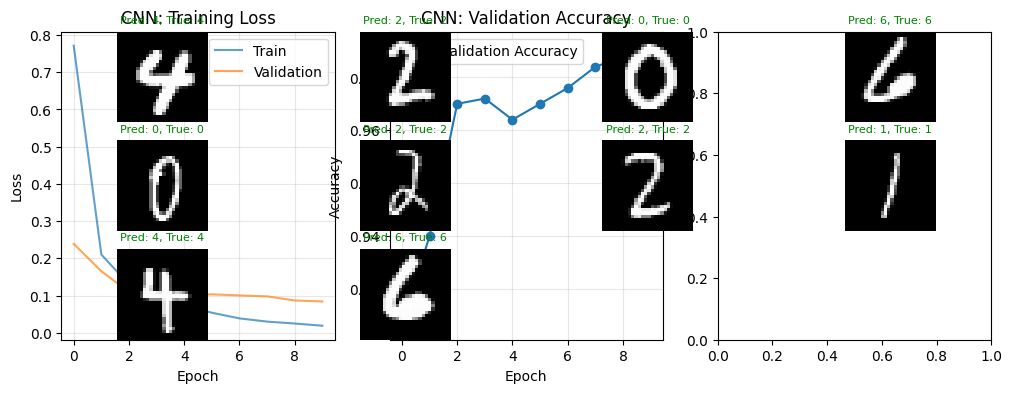


CNN training completed successfully!


In [5]:
print("\n" + "=" * 60)
print("Use Case 2: MNIST Digit Classification (CNN)")
print("=" * 60)

# Load and preprocess MNIST data
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize images: 0-255 → 0-1 range
x_train_full = x_train_full.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Use subset for faster training
n_train = 5000
n_val = 1000
x_train = x_train_full[:n_train]
y_train = y_train_full[:n_train]
x_val = x_train_full[n_train:n_train+n_val]
y_val = y_train_full[n_train:n_train+n_val]

# Add channel dimension for CNN: (N, 28, 28) → (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-hot encode labels
def one_hot_encode(y, num_classes=10):
    return tf.one_hot(y, num_classes).numpy()

y_train_onehot = one_hot_encode(y_train)
y_val_onehot = one_hot_encode(y_val)

print(f"\nDataset Info:")
print(f"  Training: {x_train.shape} → {y_train_onehot.shape}")
print(f"  Validation: {x_val.shape} → {y_val_onehot.shape}")
print(f"  Test: {x_test.shape}")

# Build CNN model
class CNNModel(tf.keras.Model):
    def __init__(self, num_classes=10):
        super().__init__()
        # First convolutional block
        self.conv1 = tf.keras.layers.Conv2D(32, (3, 3), padding='same')
        self.relu1 = tf.keras.layers.Activation('relu')
        self.pool1 = tf.keras.layers.MaxPooling2D((2, 2))
        
        # Second convolutional block
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')
        self.relu2 = tf.keras.layers.Activation('relu')
        self.pool2 = tf.keras.layers.MaxPooling2D((2, 2))
        
        # Fully connected layers
        self.flatten = tf.keras.layers.Flatten()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dropout = tf.keras.layers.Dropout(0.2)
        self.dense2 = tf.keras.layers.Dense(num_classes)
    
    def call(self, inputs, training=False):
        # Conv block 1
        x = self.conv1(inputs)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Conv block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Dense layers
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dropout(x, training=training)
        
        # Output (logits)
        return self.dense2(x)

# Custom training function with metrics
def train_step_cnn(model, x, y, optimizer, loss_fn):
    """Single training step for CNN"""
    with tf.GradientTape() as tape:
        # Forward pass
        logits = model(x, training=True)
        
        # Cross-entropy loss
        loss = loss_fn(y, logits)
    
    # Compute gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # Gradient clipping
    gradients = [tf.clip_by_norm(g, 1.0) for g in gradients]
    
    # Apply gradients
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    return loss

def evaluate_cnn(model, x, y, loss_fn):
    """Evaluate model on dataset"""
    logits = model(x, training=False)
    loss = loss_fn(y, logits)
    
    # Accuracy
    predictions = tf.argmax(logits, axis=-1)
    targets = tf.argmax(y, axis=-1)
    accuracy = tf.reduce_mean(tf.cast(predictions == targets, tf.float32))
    
    return loss, accuracy

# Initialize model, optimizer, and loss function
cnn_model = CNNModel(num_classes=10)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

# Training loop
print("\nTraining CNN Model...")
batch_size = 64
train_losses = []
val_losses = []
val_accuracies = []

n_epochs = 10
for epoch in range(n_epochs):
    epoch_loss = 0
    n_batches = 0
    
    # Training batches
    for i in range(0, len(x_train), batch_size):
        x_batch = tf.constant(x_train[i:i+batch_size])
        y_batch = tf.constant(y_train_onehot[i:i+batch_size])
        
        loss = train_step_cnn(cnn_model, x_batch, y_batch, optimizer, loss_fn)
        epoch_loss += loss.numpy()
        n_batches += 1
    
    train_loss = epoch_loss / n_batches
    train_losses.append(train_loss)
    
    # Validation
    val_loss, val_acc = evaluate_cnn(
        cnn_model,
        tf.constant(x_val),
        tf.constant(y_val_onehot),
        loss_fn
    )
    val_losses.append(val_loss.numpy())
    val_accuracies.append(val_acc.numpy())
    
    print(f"Epoch {epoch+1:2d}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss.numpy():.4f}, Val Acc = {val_acc.numpy():.4f}")

# Test evaluation
test_loss, test_acc = evaluate_cnn(
    cnn_model,
    tf.constant(x_test),
    tf.constant(one_hot_encode(y_test)),
    loss_fn
)
print(f"\nTest Loss: {test_loss.numpy():.4f}, Test Accuracy: {test_acc.numpy():.4f}")

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train', alpha=0.7)
plt.plot(val_losses, label='Validation', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN: Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN: Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Sample predictions
plt.subplot(1, 3, 3)
sample_idx = np.random.choice(len(x_test), 10, replace=False)
sample_images = x_test[sample_idx]
sample_labels = y_test[sample_idx]
sample_logits = cnn_model(tf.constant(sample_images), training=False)
sample_predictions = tf.argmax(sample_logits, axis=-1).numpy()

for i in range(min(10, len(sample_idx))):
    plt.subplot(3, 4, i+1)
    plt.imshow(sample_images[i, :, :, 0], cmap='gray')
    pred = sample_predictions[i]
    actual = sample_labels[i]
    color = 'green' if pred == actual else 'red'
    plt.title(f'Pred: {pred}, True: {actual}', color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nCNN training completed successfully!")

## Section 10: Real-Time Use Case - Image Classification with CNN

**Problem:** Classify handwritten digits from MNIST dataset

**Model Architecture:**
- Conv2D → ReLU → MaxPool
- Conv2D → ReLU → MaxPool  
- Flatten → Dense (128 units, ReLU) → Dense (10 units, Softmax)

**Edge Cases Handled:**
- Data normalization (0-255 → 0-1 range)
- One-hot encoding for labels
- Input validation for batch sizes
- Gradient clipping for stability

Use Case 1: House Price Prediction (Linear Regression)

Dataset created:
  Training samples: (160, 3)
  Validation samples: (40, 3)
  Features: area (sqft), bedrooms, age (years)

Training Linear Regression Model...
Epoch  50: Train Loss = 0.233138, Val Loss = 0.248991
Epoch 100: Train Loss = 0.029069, Val Loss = 0.028897
Epoch 150: Train Loss = 0.017876, Val Loss = 0.014616
Epoch 200: Train Loss = 0.017783, Val Loss = 0.014188

Final Model:
  Weights: [ 0.85808307  0.33905888 -0.2513186 ]
  Bias: [-5.42214e-07]
  Training Loss: 0.017783
  Validation Loss: 0.014188


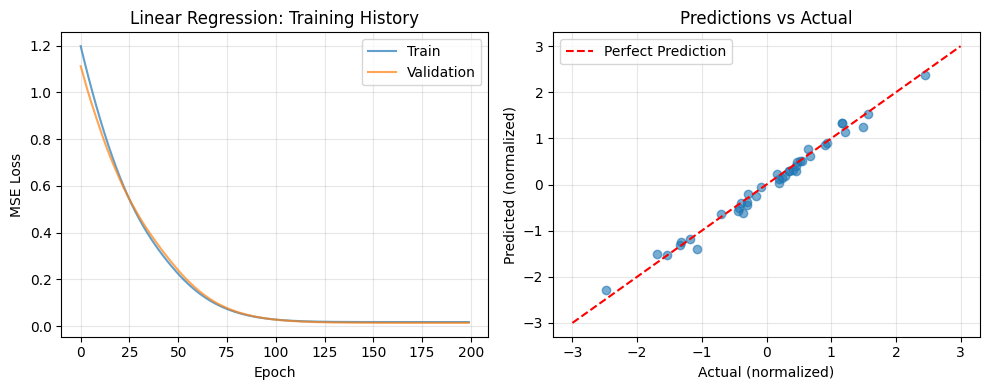


Validation R² Score: 0.9851


In [6]:
print("=" * 60)
print("Use Case 1: House Price Prediction (Linear Regression)")
print("=" * 60)

# Generate synthetic house price data
# Features: [house_area_sqft, num_bedrooms, age_years]
np.random.seed(42)
n_samples = 200
n_features = 3

X_raw = np.random.randn(n_samples, n_features).astype(np.float32)
X_raw[:, 0] = X_raw[:, 0] * 1000 + 2000  # Area: 1000-3000 sqft
X_raw[:, 1] = X_raw[:, 1] * 1 + 3         # Bedrooms: 2-4
X_raw[:, 2] = X_raw[:, 2] * 20 + 40       # Age: 20-60 years

# True linear relationship: price = 150*area + 50000*bedrooms - 2000*age + noise
w_true = np.array([150, 50000, -2000], dtype=np.float32)
b_true = 100000.0
y = (X_raw @ w_true + b_true + np.random.randn(n_samples) * 20000).astype(np.float32)

# Split data
train_size = int(0.8 * n_samples)
X_train_raw, X_val_raw = X_raw[:train_size], X_raw[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Normalize features (important for numerical stability)
X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0) + 1e-8
X_train = (X_train_raw - X_mean) / X_std
X_val = (X_val_raw - X_mean) / X_std

# Normalize targets
y_mean = y_train.mean()
y_std = y_train.std()
y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std

print(f"\nDataset created:")
print(f"  Training samples: {X_train.shape}")
print(f"  Validation samples: {X_val.shape}")
print(f"  Features: area (sqft), bedrooms, age (years)")

# Build linear regression model with custom training
# Use build() + add_weight() for proper Keras 3 weight tracking
class LinearRegression(tf.keras.Model):
    def __init__(self, n_features):
        super().__init__()
        self.n_features = n_features

    def build(self, input_shape):
        self.w = self.add_weight(
            name='weights',
            shape=(self.n_features, 1),
            initializer=tf.initializers.RandomNormal(stddev=0.1),
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        return tf.matmul(x, self.w) + self.b

# Custom training with edge case handling
model = LinearRegression(n_features=3)
# Build by calling with a dummy input
model(tf.constant(X_train[:1]))
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

def custom_train_step(X, y):
    """Custom training step with edge case handling"""
    with tf.GradientTape() as tape:
        # Forward pass
        predictions = model(X)
        
        # MSE loss
        loss = tf.reduce_mean((predictions - y)**2)
    
    # Compute gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # Gradient clipping to prevent explosion
    gradients = [tf.clip_by_norm(g, 1.0) for g in gradients]
    
    # Apply gradients
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    return loss

# Training loop
print("\nTraining Linear Regression Model...")
train_losses = []
val_losses = []
patience = 20
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(200):
    # Training
    train_loss = custom_train_step(
        tf.constant(X_train),
        tf.constant(y_train_norm.reshape(-1, 1))
    )
    train_losses.append(train_loss.numpy())
    
    # Validation
    val_predictions = model(tf.constant(X_val))
    val_loss = tf.reduce_mean((val_predictions - tf.constant(y_val_norm.reshape(-1, 1)))**2)
    val_losses.append(val_loss.numpy())
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"  Early stopping at epoch {epoch}")
        break
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Train Loss = {train_loss.numpy():.6f}, Val Loss = {val_loss.numpy():.6f}")

print(f"\nFinal Model:")
print(f"  Weights: {model.w.numpy().flatten()}")
print(f"  Bias: {model.b.numpy()}")
print(f"  Training Loss: {train_losses[-1]:.6f}")
print(f"  Validation Loss: {val_losses[-1]:.6f}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train', alpha=0.7)
plt.plot(val_losses, label='Validation', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Linear Regression: Training History')
plt.legend()
plt.grid(True, alpha=0.3)

# Predictions vs actual
val_predictions = model(tf.constant(X_val)).numpy().flatten()
val_actual = y_val_norm.flatten()

plt.subplot(1, 2, 2)
plt.scatter(val_actual, val_predictions, alpha=0.6)
plt.plot([-3, 3], [-3, 3], 'r--', label='Perfect Prediction')
plt.xlabel('Actual (normalized)')
plt.ylabel('Predicted (normalized)')
plt.title('Predictions vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate R² score
ss_res = tf.reduce_sum((val_predictions - val_actual)**2)
ss_tot = tf.reduce_sum((val_actual - tf.reduce_mean(val_actual))**2)
r2_score = 1 - (ss_res / ss_tot)
print(f"\nValidation R² Score: {r2_score.numpy():.4f}")


## Section 9: Real-Time Use Case - Linear Regression with Custom Training

**Problem:** Predict house prices from features using linear regression

**Approach:**
- Model: $\hat{y} = Xw + b$
- Loss: $L = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
- Optimization: Gradient descent with momentum

**Edge Cases Handled:**
- Feature normalization to prevent numerical issues
- Gradient clipping to prevent explosion
- Validation set for early stopping

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

print("=" * 60)
print("Edge Cases: Shape Mismatches and Type Casting")
print("=" * 60)

# 1. Common shape mismatch errors
print("\nShape Mismatch Examples:")

# Error 1: Matrix multiplication dimension mismatch
A = tf.constant([[1, 2, 3], [4, 5, 6]])  # Shape (2, 3)
B = tf.constant([[1, 2], [3, 4]])        # Shape (2, 2) - WRONG for matmul

print(f"Matrix A shape: {A.shape}")
print(f"Matrix B shape: {B.shape}")

try:
    result = tf.matmul(A, B)
except Exception as e:
    print(f"  Error: {e}")
    print(f"  Fix: B must have shape (3, 2) for A @ B to work")

# Correct shapes
B_correct = tf.constant([[1, 2], [3, 4], [5, 6]])  # Shape (3, 2)
result = tf.matmul(A, B_correct)
print(f"  Fixed: A {A.shape} @ B {B_correct.shape} = {result.shape}")

# Error 2: Addition dimension mismatch (with broadcast rules)
print(f"\n\nBroadcasting Examples:")

x = tf.constant([[1, 2, 3]])        # Shape (1, 3)
y = tf.constant([[1], [2], [3]])    # Shape (3, 1)

result = x + y  # Broadcasting to (3, 3)
print(f"Shape (1, 3) + Shape (3, 1) = Shape {result.shape}")
print(f"Result:\n{result}")

# Error: Non-broadcastable shapes
a = tf.constant([[1, 2, 3]])        # Shape (1, 3)
b = tf.constant([[1, 2], [3, 4]])   # Shape (2, 2)

try:
    result = a + b
except Exception as e:
    print(f"\nShape (1, 3) + Shape (2, 2): Error: {type(e).__name__}")

# 2. Reshaping, expand_dims, squeeze
print(f"\n\nFixing Shape Mismatches with Reshape Operations:")

tensor = tf.constant([1, 2, 3, 4, 5, 6])
print(f"Original tensor shape: {tensor.shape}")

# Reshape
reshaped = tf.reshape(tensor, (2, 3))
print(f"After reshape(2, 3): {reshaped.shape}")

# expand_dims: add new dimension of size 1
expanded = tf.expand_dims(reshaped, axis=0)  # Add batch dimension
print(f"After expand_dims(axis=0): {expanded.shape}")

expanded2 = tf.expand_dims(reshaped, axis=-1)  # Add to end
print(f"After expand_dims(axis=-1): {expanded2.shape}")

# squeeze: remove dimensions of size 1
squeezed = tf.squeeze(expanded, axis=0)
print(f"After squeeze(axis=0): {squeezed.shape}")

# 3. Type casting and precision
print(f"\n\nType Casting and Precision:")

# Float to Int conversion
float_val = tf.constant(3.7)
int_val = tf.cast(float_val, tf.int32)
print(f"Float {float_val.numpy()} → Int32 {int_val.numpy()} (precision loss)")

# Safe type conversion example
def safe_cast(tensor, target_dtype, clip_range=None):
    """Safely cast tensor to target dtype"""
    if clip_range:
        tensor = tf.clip_by_value(tensor, clip_range[0], clip_range[1])
    
    return tf.cast(tensor, target_dtype)

# Example: Convert float probabilities (0-1) to uint8 (0-255)
probabilities = tf.constant([0.1, 0.5, 0.9])
uint8_values = safe_cast(probabilities * 255, tf.uint8)
print(f"Probabilities {probabilities.numpy()} → uint8 {uint8_values.numpy()}")

# 4. Handling shape inference
print(f"\n\nShape Inference and Dynamic Shapes:")

# Dynamic shape
def process_batch(batch):
    """Process variable-size batches"""
    batch_size = tf.shape(batch)[0]  # Dynamic shape (not known at graph build time)
    static_shape = batch.shape[0]    # Static shape (known at graph build time)
    
    print(f"  Dynamic shape (batch size): {batch_size}")
    print(f"  Static shape (batch size): {static_shape}")
    
    return batch

batch1 = tf.random.normal((32, 28, 28, 1))
batch2 = tf.random.normal((16, 28, 28, 1))

print("Batch 1:")
process_batch(batch1)
print("Batch 2:")
process_batch(batch2)

Edge Cases: Shape Mismatches and Type Casting

Shape Mismatch Examples:
Matrix A shape: (2, 3)
Matrix B shape: (2, 2)
  Error: {{function_node __wrapped__MatMul_device_/job:localhost/replica:0/task:0/device:CPU:0}} Matrix size-incompatible: In[0]: [2,3], In[1]: [2,2] [Op:MatMul] name: 
  Fix: B must have shape (3, 2) for A @ B to work
  Fixed: A (2, 3) @ B (3, 2) = (2, 2)


Broadcasting Examples:
Shape (1, 3) + Shape (3, 1) = Shape (3, 3)
Result:
[[2 3 4]
 [3 4 5]
 [4 5 6]]

Shape (1, 3) + Shape (2, 2): Error: InvalidArgumentError


Fixing Shape Mismatches with Reshape Operations:
Original tensor shape: (6,)
After reshape(2, 3): (2, 3)
After expand_dims(axis=0): (1, 2, 3)
After expand_dims(axis=-1): (2, 3, 1)
After squeeze(axis=0): (2, 3)


Type Casting and Precision:
Float 3.700000047683716 → Int32 3 (precision loss)
Probabilities [0.1 0.5 0.9] → uint8 [ 25 127 229]


Shape Inference and Dynamic Shapes:
Batch 1:
  Dynamic shape (batch size): 32
  Static shape (batch size): 32
Batch 2:

<tf.Tensor: shape=(16, 28, 28, 1), dtype=float32, numpy=
array([[[[-0.36137015],
         [-1.0685778 ],
         [-1.605182  ],
         ...,
         [-0.43859223],
         [ 2.1708972 ],
         [-1.1498448 ]],

        [[-0.44388407],
         [-1.3732938 ],
         [ 0.56312716],
         ...,
         [ 0.5468077 ],
         [-0.13481186],
         [-1.4657462 ]],

        [[ 1.0208714 ],
         [-2.1132464 ],
         [ 1.0810316 ],
         ...,
         [-0.81809914],
         [ 0.29654366],
         [ 0.9247153 ]],

        ...,

        [[ 0.16491629],
         [ 0.5377249 ],
         [ 1.3296554 ],
         ...,
         [-0.67247033],
         [-0.11823342],
         [ 0.284763  ]],

        [[-1.6974263 ],
         [-0.3944899 ],
         [ 0.2338898 ],
         ...,
         [ 0.60822904],
         [ 0.73038286],
         [-0.83077294]],

        [[-0.1544465 ],
         [ 0.49490836],
         [ 1.2896131 ],
         ...,
         [ 0.46801543],
         [-0.333708

In [8]:
print("=" * 60)
print("Edge Cases — Basic → Advanced → Enterprise")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# BASIC: Type Casting Precision Traps
# ─────────────────────────────────────────────────────────────
print("\n── BASIC: Type Casting Precision Traps ──")

# Float → Int truncates toward zero, not rounds
x_vals = tf.constant([1.9, -1.9, 0.5, -0.5, 2.5])
print(f"Values:          {x_vals.numpy()}")
print(f"tf.cast → int32: {tf.cast(x_vals, tf.int32).numpy()}  ← truncates, does NOT round")
print(f"round → int32:   {tf.cast(tf.round(x_vals), tf.int32).numpy()}  ← banker's rounding (even)")

# Integer division floor
a_i = tf.constant(7, dtype=tf.int32)
b_i = tf.constant(2, dtype=tf.int32)
print(f"\nInteger division: 7 // 2 = {(a_i // b_i).numpy()} (floor), not 3.5")
print(f"Float division:   7 / 2  = {(tf.cast(a_i, tf.float32) / tf.cast(b_i, tf.float32)).numpy()}")

# Boolean mask vs gather
print("\n── BASIC: Boolean Masking vs Gather ──")
t_basic = tf.constant([10, 20, 30, 40, 50])
mask_b = tf.constant([True, False, True, False, True])
selected = tf.boolean_mask(t_basic, mask_b)
indices = tf.where(mask_b)
gathered = tf.gather(t_basic, tf.squeeze(indices, axis=1))
print(f"boolean_mask result: {selected.numpy()}")
print(f"gather via tf.where: {gathered.numpy()}")
print(f"Both equivalent — gather supports batching, boolean_mask is simpler")

# NaN / Inf sources
print("\n── BASIC: NaN and Inf Sources ──")
sources = {
    "0 / 0":    tf.constant(0.0) / tf.constant(0.0),
    "log(0)":   tf.math.log(tf.constant(0.0)),
    "log(-1)":  tf.math.log(tf.constant(-1.0)),
    "sqrt(-1)": tf.math.sqrt(tf.constant(-1.0)),
    "1 / 0":    tf.constant(1.0) / tf.constant(0.0),
}
for name, val in sources.items():
    print(f"  {name:12s} → {val.numpy():>9}  nan={tf.math.is_nan(val).numpy()}, inf={tf.math.is_inf(val).numpy()}")

bad = tf.constant([1.0, float('nan'), float('inf'), -float('inf')])
fixed = tf.where(tf.math.is_finite(bad), bad, tf.zeros_like(bad))
print(f"\nOriginal: {bad.numpy()}")
print(f"Fixed:    {fixed.numpy()}")


# ─────────────────────────────────────────────────────────────
# ADVANCED: ML-Specific Numerical Hazards
# ─────────────────────────────────────────────────────────────
print("\n── ADVANCED: Float16 Overflow & Underflow ──")

fp32_test_vals = [1e-10, 1e-5, 1.0, 1e4, 1e8]
print(f"{'fp32 value':>12}  {'fp16 value':>14}  status")
for v in fp32_test_vals:
    fp32 = tf.constant(v, tf.float32)
    fp16 = tf.cast(fp32, tf.float16)
    fp32_back = tf.cast(fp16, tf.float32)
    if fp32_back.numpy() == 0.0 and v != 0.0:
        status = "UNDERFLOW → 0"
    elif not tf.math.is_finite(fp16).numpy():
        status = "OVERFLOW → inf"
    else:
        err = abs(v - fp32_back.numpy()) / (abs(v) + 1e-30)
        status = f"precision err={err:.2e}"
    print(f"  {v:12.2e}  {fp16.numpy():14}  {status}")

print(f"\nfp16 range: {np.finfo(np.float16).tiny:.2e} – {np.finfo(np.float16).max:.2e}")
print(f"fp32 range: {np.finfo(np.float32).tiny:.2e} – {np.finfo(np.float32).max:.2e}")

loss_fp16_raw = tf.constant(1e-6, tf.float16)
scale_f16 = tf.constant(2.0**15, tf.float16)
scaled_f16 = loss_fp16_raw * scale_f16
print(f"\nLoss scaling: {loss_fp16_raw.numpy()} × {scale_f16.numpy()} = {scaled_f16.numpy():.4f}  ← now representable")


print("\n── ADVANCED: Gradient Explosion Detection & Clipping ──")

def make_small_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(8,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

x_adv = tf.random.normal((64, 8))
y_adv = tf.random.normal((64, 1))

model_explode = make_small_model()
opt_explode = tf.keras.optimizers.SGD(learning_rate=50.0)

print("Without clipping (LR=50.0):")
for step in range(3):
    with tf.GradientTape() as tape:
        loss_adv = tf.reduce_mean((model_explode(x_adv, training=True) - y_adv) ** 2)
    grads_adv = tape.gradient(loss_adv, model_explode.trainable_variables)
    global_norm_adv = tf.linalg.global_norm(grads_adv).numpy()
    print(f"  step {step+1}: loss={loss_adv.numpy():.3e}, global_grad_norm={global_norm_adv:.3e}")
    opt_explode.apply_gradients(zip(grads_adv, model_explode.trainable_variables))

model_clipped = make_small_model()
opt_clipped = tf.keras.optimizers.SGD(learning_rate=50.0, clipnorm=1.0)

print("\nWith clipnorm=1.0 (same LR=50.0):")
for step in range(3):
    with tf.GradientTape() as tape:
        loss_adv = tf.reduce_mean((model_clipped(x_adv, training=True) - y_adv) ** 2)
    grads_adv = tape.gradient(loss_adv, model_clipped.trainable_variables)
    clipped_grads, global_norm_adv = tf.clip_by_global_norm(grads_adv, 1.0)
    print(f"  step {step+1}: loss={loss_adv.numpy():.3e}, global_grad_norm={global_norm_adv:.3e} → clipped to 1.0")
    opt_clipped.apply_gradients(zip(clipped_grads, model_clipped.trainable_variables))


print("\n── ADVANCED: @tf.function Side-Effect Trap ──")

trace_log = []

@tf.function
def fn_with_side_effect(x):
    trace_log.append("traced!")  # Python side-effect — runs ONLY during tracing
    return x * 2

for v in [1.0, 2.0, 3.0]:
    fn_with_side_effect(tf.constant(v))
print(f"Python append (3 calls, 1 trace): {trace_log}")

@tf.function
def fn_correct_logging(x):
    tf.print("  [graph log] x =", x)  # runs on every call inside the graph
    return x * 2

print("tf.print output (every call):")
for v in [1.0, 2.0, 3.0]:
    fn_correct_logging(tf.constant(v))

# tf.range vs Python range inside @tf.function
@tf.function
def dynamic_loop(n):
    total = tf.constant(0.0)
    for i in tf.range(n):           # dynamic: handled at graph runtime
        total += tf.cast(i, tf.float32)
    return total

@tf.function
def static_loop(n):
    total = tf.constant(0.0)
    for i in range(n):              # static: unrolled at trace time
        total += tf.constant(float(i))
    return total

print(f"\ntf.range(10) sum:       {dynamic_loop(tf.constant(10)).numpy()}")
print(f"Python range(10) sum:   {static_loop(10).numpy()}")
print("Rule: use tf.range inside @tf.function for variable-length loops")


print("\n── ADVANCED: Numerically Stable Softmax & Cross-Entropy ──")

def naive_softmax(x):
    return tf.exp(x) / tf.reduce_sum(tf.exp(x))

def stable_softmax(x):
    x_shifted = x - tf.reduce_max(x)
    ex = tf.exp(x_shifted)
    return ex / tf.reduce_sum(ex)

large_logits = tf.constant([1000.0, 1001.0, 999.0])
print(f"Logits: {large_logits.numpy()}")
print(f"naive_softmax:  {naive_softmax(large_logits).numpy()}  ← NaN (exp overflow)")
print(f"stable_softmax: {stable_softmax(large_logits).numpy()}")
print(f"tf.nn.softmax:  {tf.nn.softmax(large_logits).numpy()}  ← always stable, prefer this")

logits_ex = tf.constant([[3.0, 1.0, 0.2]])
labels_ex = tf.constant([[1.0, 0.0, 0.0]])
probs_ex = tf.nn.softmax(logits_ex)
loss_unstable = tf.keras.losses.categorical_crossentropy(labels_ex, probs_ex, from_logits=False)
loss_stable   = tf.keras.losses.categorical_crossentropy(labels_ex, logits_ex, from_logits=True)
print(f"\nCross-entropy from_logits=False: {loss_unstable.numpy()[0]:.6f}")
print(f"Cross-entropy from_logits=True:  {loss_stable.numpy()[0]:.6f}  ← stable fused path")
print("Rule: ALWAYS use from_logits=True in production")


# ─────────────────────────────────────────────────────────────
# ENTERPRISE: Production Reliability Patterns
# ─────────────────────────────────────────────────────────────
print("\n── ENTERPRISE: NaN-Guard Training Loop ──")

class RobustTrainer:
    """
    Production training loop with:
    - Per-step NaN/Inf gradient detection and skip
    - Adaptive loss scaling (reduce on NaN, slowly recover)
    - Consecutive failure circuit breaker
    """
    def __init__(self, model, optimizer, max_grad_norm=5.0, max_skips=3):
        self.model = model
        self.optimizer = optimizer
        self.max_grad_norm = max_grad_norm
        self.max_skips = max_skips
        self._loss_scale = tf.Variable(1024.0, trainable=False, dtype=tf.float32)
        self._skip_streak = 0
        self.metrics = {"skipped": 0, "total": 0, "nan_losses": 0}

    @tf.function
    def _forward_backward(self, x, y):
        with tf.GradientTape() as tape:
            pred = self.model(x, training=True)
            loss = tf.reduce_mean(tf.keras.losses.mse(y, pred)) * self._loss_scale
        grads = tape.gradient(loss, self.model.trainable_variables)
        return loss / self._loss_scale, grads

    def train_step(self, x, y):
        self.metrics["total"] += 1
        loss_val, grads = self._forward_backward(x, y)

        if not tf.math.is_finite(loss_val):
            self.metrics["nan_losses"] += 1
            self._skip_streak += 1
            if self._skip_streak >= self.max_skips:
                raise RuntimeError(f"Non-finite loss for {self._skip_streak} consecutive steps")
            return None

        nan_flags = tf.stack([
            tf.reduce_any(tf.math.logical_or(tf.math.is_nan(g), tf.math.is_inf(g)))
            for g in grads if g is not None
        ])
        if tf.reduce_any(nan_flags):
            self._loss_scale.assign(self._loss_scale / 2.0)
            self.metrics["skipped"] += 1
            self._skip_streak += 1
            return None

        grads_clipped, global_norm_val = tf.clip_by_global_norm(grads, self.max_grad_norm)
        self.optimizer.apply_gradients(zip(grads_clipped, self.model.trainable_variables))
        self._loss_scale.assign_add(0.001 * self._loss_scale)
        self._skip_streak = 0
        return loss_val, global_norm_val

ent_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(6,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])
ent_trainer = RobustTrainer(ent_model, tf.keras.optimizers.Adam(0.001))
x_ent = tf.random.normal((128, 6))
y_ent = tf.random.normal((128, 1))

for step in range(5):
    result = ent_trainer.train_step(x_ent, y_ent)
    if result is not None:
        loss_v, norm_v = result
        print(f"  Step {step+1}: loss={loss_v.numpy():.4f}, grad_norm={norm_v.numpy():.4f}, scale={ent_trainer._loss_scale.numpy():.1f}")
    else:
        print(f"  Step {step+1}: skipped")
print(f"  Summary → total={ent_trainer.metrics['total']}, skipped={ent_trainer.metrics['skipped']}, nan_losses={ent_trainer.metrics['nan_losses']}")


print("\n── ENTERPRISE: Custom Gradient for Non-Differentiable Ops ──")

@tf.custom_gradient
def round_ste(x):
    """
    Round with Straight-Through Estimator (STE).
    Forward:  tf.round(x)  — non-differentiable discrete step.
    Backward: pass gradient unchanged, bypassing rounding.
    Used in:  Quantization-Aware Training (QAT), BinaryNet, discrete VAEs.
    """
    def grad(dy):
        return dy
    return tf.round(x), grad

@tf.custom_gradient
def binary_threshold(x):
    """
    Sign function with clipped STE (BinaryNet style).
    Forward:  +1 / -1. Backward: only where |x| <= 1.
    """
    def grad(dy):
        return dy * tf.cast(tf.abs(x) <= 1.0, x.dtype)
    return tf.sign(x), grad

x_qat = tf.Variable([0.3, 0.7, 1.2, -0.6, 2.1])

with tf.GradientTape() as tape:
    q = round_ste(x_qat)
    loss_q = tf.reduce_mean(q ** 2)
g_ste = tape.gradient(loss_q, x_qat)

with tf.GradientTape() as tape:
    b_thresh = binary_threshold(x_qat)
    loss_b = tf.reduce_mean(b_thresh ** 2)
g_bin = tape.gradient(loss_b, x_qat)

print(f"Input:             {x_qat.numpy()}")
print(f"round_ste output:  {round_ste(x_qat).numpy()}")
print(f"STE gradient:      {g_ste.numpy()}  ← flows through rounding")
print(f"binary output:     {binary_threshold(x_qat).numpy()}")
print(f"binary gradient:   {g_bin.numpy()}  ← zero outside |x|<=1")
print("Use cases: QAT for edge inference, discrete latent spaces, BinaryNet")


print("\n── ENTERPRISE: Checkpoint Fault-Tolerance ──")

save_model_ent = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(1)
])
_ = save_model_ent(tf.zeros((1, 4)))   # force build
original_weights_ent = save_model_ent.get_weights()

ckpt_ent = tf.train.Checkpoint(model=save_model_ent)
# Use a directory + file prefix, then restore with CheckpointManager
ckpt_manager = tf.train.CheckpointManager(ckpt_ent, "/tmp/tf_edge_ckpt_dir", max_to_keep=1)
save_path_ent = ckpt_manager.save()
print(f"Checkpoint saved: {save_path_ent}")

# Simulate crash: zero out weights
save_model_ent.set_weights([w * 0 for w in original_weights_ent])
print(f"After crash (zeroed): {save_model_ent.trainable_variables[0].numpy()[0, :3]}")

# Restore via manager (production pattern)
ckpt_ent.restore(ckpt_manager.latest_checkpoint).assert_consumed()
restored_weights_ent = save_model_ent.get_weights()
max_diff = max(np.max(np.abs(o - r)) for o, r in zip(original_weights_ent, restored_weights_ent))
print(f"After restore:        {save_model_ent.trainable_variables[0].numpy()[0, :3]}")
print(f"Max weight diff: {max_diff:.2e}  ← should be ~0")
print("Rule: tf.train.CheckpointManager for automatic save rotation and safe restore")


print("\n── ENTERPRISE: Distributed Gradient Aggregation Consistency ──")

n_replicas = 4
per_replica_grads = [tf.random.normal((8, 4)) for _ in range(n_replicas)]

# Naive: stack and mean
naive_mean = tf.reduce_mean(tf.stack(per_replica_grads), axis=0)

# Pairwise reduction (numerically stable, mirrors NCCL allreduce)
def pairwise_reduce(tensors):
    while len(tensors) > 1:
        pairs = []
        for i in range(0, len(tensors) - 1, 2):
            pairs.append((tensors[i] + tensors[i + 1]) / 2.0)
        if len(tensors) % 2 == 1:
            pairs.append(tensors[-1])
        tensors = pairs
    return tensors[0]

pairwise_mean = pairwise_reduce(per_replica_grads)
diff = tf.reduce_max(tf.abs(naive_mean - pairwise_mean)).numpy()
print(f"Gradient mean diff (naive vs pairwise): {diff:.2e}")
print("At scale (fp16 + 1000s of GPUs), pairwise reduction prevents catastrophic cancellation")

tf.random.set_seed(42)
seed_a = tf.random.normal((2,)).numpy()
tf.random.set_seed(42)
seed_b = tf.random.normal((2,)).numpy()
print(f"\nSame global seed → identical values: {np.allclose(seed_a, seed_b)}")
print("Production rule: set global + op-level seeds for fully reproducible distributed runs")


Edge Cases — Basic → Advanced → Enterprise

── BASIC: Type Casting Precision Traps ──
Values:          [ 1.9 -1.9  0.5 -0.5  2.5]
tf.cast → int32: [ 1 -1  0  0  2]  ← truncates, does NOT round
round → int32:   [ 2 -2  0  0  2]  ← banker's rounding (even)

Integer division: 7 // 2 = 3 (floor), not 3.5
Float division:   7 / 2  = 3.5

── BASIC: Boolean Masking vs Gather ──
boolean_mask result: [10 30 50]
gather via tf.where: [10 30 50]
Both equivalent — gather supports batching, boolean_mask is simpler

── BASIC: NaN and Inf Sources ──
  0 / 0        →       nan  nan=True, inf=False
  log(0)       →      -inf  nan=False, inf=True
  log(-1)      →       nan  nan=True, inf=False
  sqrt(-1)     →       nan  nan=True, inf=False
  1 / 0        →       inf  nan=False, inf=True

Original: [  1.  nan  inf -inf]
Fixed:    [1. 0. 0. 0.]

── ADVANCED: Float16 Overflow & Underflow ──
  fp32 value      fp16 value  status
      1.00e-10             0.0  UNDERFLOW → 0
      1.00e-05  1.0013580322265625e

# TensorFlow Core: Advanced Topics, Use Cases & Performance

## Overview
This notebook covers advanced TensorFlow topics:
- **Edge Cases**: Shape mismatches, type casting, precision issues
- **Real-World Use Cases**: Linear regression, image classification
- **Performance Optimization**: Graph execution, mixed precision, profiling
- **Benchmarking**: Measuring and improving model performance

**References:**
- [Performance Guide](https://www.tensorflow.org/guide/function)
- [Mixed Precision Training](https://www.tensorflow.org/guide/mixed_precision)
- [TensorFlow Profiler](https://www.tensorflow.org/tensorboard/profiler)

## Keras Layers Content Moved to Separate Notebook

Keras built-in layers tutorial is now maintained in:
- foundation/08-keras-3-builtin-layers.ipynb

On-point purpose for this notebook (07):
- 07 focuses on TensorFlow core advanced runtime topics such as graph execution, optimization, mixed precision, checkpointing, and distributed workflows.
- Keras layer selection, layer-level do and do not patterns, normal and edge cases are separated to keep 07 focused and easier to revise.